In [13]:
import pairs_trading
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [14]:
tickers = ['BTC-USD', 'ETH-USD', 'XRP-USD', 'LTC-USD', 'BCH-USD']
years = 170/365

In [15]:
%%capture
# Initialize the backtester
backtester = pairs_trading.PairsBacktest(tickers, years, lookback_window=20, entry_z=2)
results1 = backtester.data_loader()
results = backtester.compute_metrics()


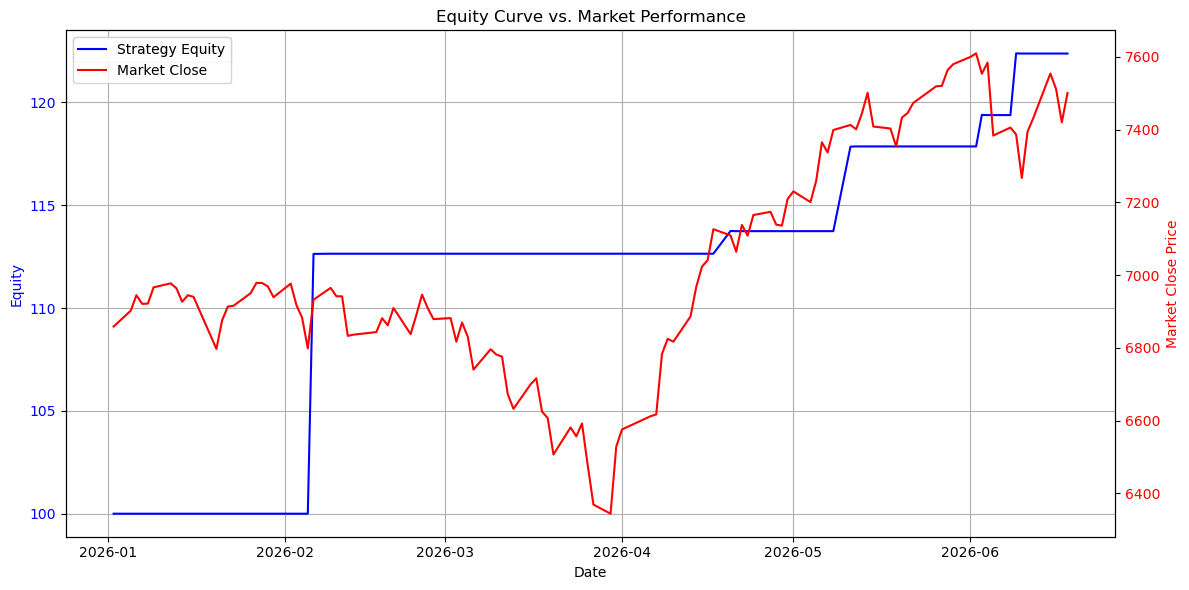

The tickers with the highest correlation, and the ones used in the pairs-trading strategy were LTC-USD and XRP-USD. This strategy used a z-score level of 2.
             Metric       Value
0      Sharpe Ratio     2.15303
1             Alpha   46.85057%
2      Total Return      22.38%
3      Max Drawdown      -0.01%
4        Start Date  2026-01-02
5          End Date  2026-06-21
6  Starting Capital     $100.00
7    Ending Capital     $122.38
8    Capital Gained      $22.38
9      Total Trades           5


In [16]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Equity Curve on primary y-axis
sns.lineplot(x=backtester.data.index, y=backtester.data['Equity'], ax=ax1, color='blue', label='Strategy Equity')
ax1.set_xlabel('Date')
ax1.set_ylabel('Equity', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)

# Create a second y-axis for Market Data
ax2 = ax1.twinx()
sns.lineplot(x=backtester.market_data.index, y=backtester.market_data['Close'].squeeze(), ax=ax2, color='red', label='Market Close')
ax2.set_ylabel('Market Close Price', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Equity Curve vs. Market Performance')

# Add legends for both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print(f"The tickers with the highest correlation, and the ones used in the pairs-trading strategy were {results1[0]} and {results1[1]}. This strategy used a z-score level of {backtester.entry_z}.")
print(results)